# This notebook shows you how to use the generate_front_training_data script


In [1]:
import subprocess
import matplotlib.pyplot as plt
import numpy as np

## Example of loading 1 sample a week for 4 weeks

In [2]:
# First you must run

# $env:AWS_ACCESS_KEY_ID="..."
# $env:AWS_SECRET_ACCESS_KEY="..."
#
# or
#
# export AWS_ACCESS_KEY_ID=...
# export AWS_SECRET_ACCESS_KEY=...


In [3]:
# 4 samples, 1 from each of 4 consecutive weeks

# temporal options ------
timestep_hours = "672"        # how many hours to load total. This example is 4 weeks
sampling_step = "168"         # stride in hours, 1 week
start_record = "1180"         # first valid wind/forcing record begins ~1180, This is also the default start of the script

# spatial options ------
target_km_res = "150"         # km resolution of our patches w and h
down_sample_res = "64"        # pixel resolution of our patches w and h
# NOTE The above are heavily dependent on each other. down_sample_res must be smaller than the smallest possible resolution created by target_km_re on the llc grid. 150 and 64 are safe. Todo it would be nice to create a function to calculate this for the user.
samples_per_snapshot = "25"   # how many patches to take from each snapshot
bias_to_high_gradients = "2"  # see documentation on sampling

# s3 output config ------
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "script_test_00/"   # should be unique for each instance of dbof you wish to create, it is just a folder in s3

s3_endpoint = "https://s3-west.nrp-nautilus.io"

# parallel ------
num_workers = 20 # How many threads would you like to create? Note : Should be <= sample_points_per_snapshot

In [6]:
# 4 samples, 1 from each of 4 consecutive weeks

# temporal options ------
#timestep_hours = "8064" # 1 year
timestep_hours = "504"
#timestep_hours = "168"

sampling_step = "168"
#sampling_step = "2016" # 3month

start_record = "1180"         # first valid wind/forcing record begins ~1180, This is also the default start of the script

# spatial options ------
target_km_res = "150"         # km resolution of our patches w and h
down_sample_res = "64"        # pixel resolution of our patches w and h
# NOTE The above are heavily dependent on each other. down_sample_res must be smaller than the smallest possible resolution created by target_km_re on the llc grid. 150 and 64 are safe. Todo it would be nice to create a function to calculate this for the user.
samples_per_snapshot = "100"   # how many patches to take from each snapshot
bias_to_high_gradients = "2"  # see documentation on sampling

# s3 output config ------
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "script_test_fast_05/"   # should be unique for each instance of dbof you wish to create, it is just a folder in s3

s3_endpoint = "https://s3-west.nrp-nautilus.io"

# parallel ------
num_workers = 1 # How many threads would you like to create? Note : Should be <= sample_points_per_snapshot todo remove this option

In [ ]:
print()
!generate-llc-dataset --sampling_step {sampling_step} --start_record {start_record} --timestep_hours {timestep_hours} --sample_points_per_snapshot {samples_per_snapshot} --bias_to_high_gradients {bias_to_high_gradients} --target_km_res {target_km_res} --down_sample_res {down_sample_res} --bucket {bucket} --folder {folder} --run_id {run_id} --s3_endpoint {s3_endpoint} --num_workers {num_workers}


In [6]:
import fsspec
import pandas as pd

fs_synch = fsspec.filesystem(
    "s3", #
    asynchronous=False,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

fs = fsspec.filesystem(
        "s3",  #
        asynchronous=True,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

In [7]:
files = fs_synch.glob(
    f"llc/native_grid_dbof_training_data/{run_id}metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)

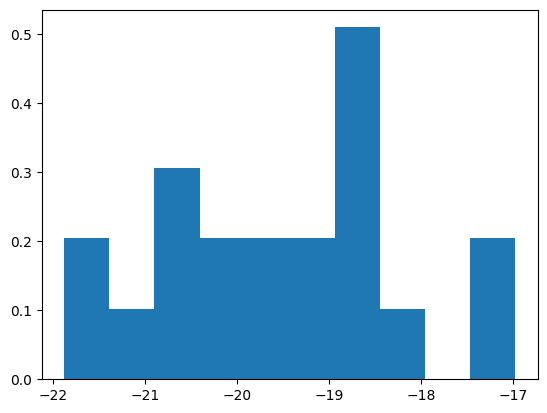

In [10]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=10, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.show()

In [9]:
import dataset_creation.zarr_dataset as zarr_dataset

In [11]:
reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset.zarr",
    fs=fs
)

img, img_id = reader.get_image(10)

imgs, ids = reader.get_images([0,1,2,3,4,5,6,7,8,9,10])


In [12]:
reader.num_images

40

In [14]:
img, img_id = reader.get_image(0)

In [15]:
img[2]

array([[11.291225, 11.293628, 11.230706, ..., 11.338554, 11.2247  ,
        11.180521],
       [11.121574, 11.12736 , 11.089065, ..., 11.287602, 11.194924,
        11.185513],
       [10.956237, 10.970136, 10.986436, ..., 11.224926, 11.183045,
        11.200046],
       ...,
       [10.797512, 10.784924, 10.785529, ..., 10.835412, 10.924855,
        11.067021],
       [10.794002, 10.79726 , 10.78387 , ..., 10.871684, 10.927983,
        10.984925],
       [10.773418, 10.795204, 10.7948  , ..., 10.857704, 10.94884 ,
        10.994901]], shape=(64, 64), dtype=float32)

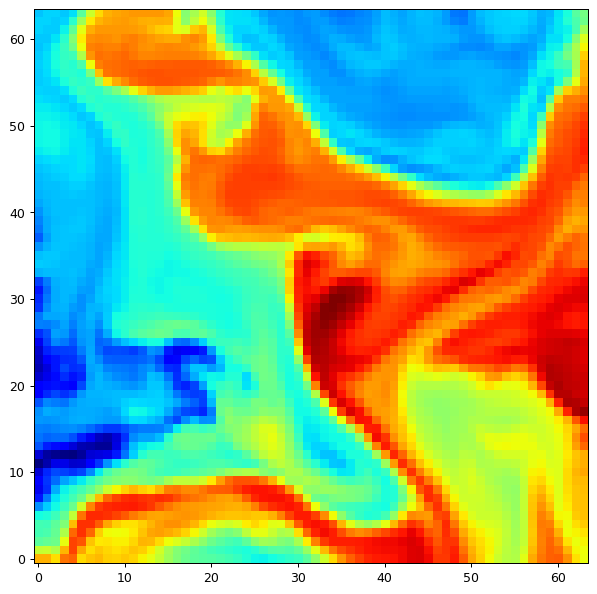

In [16]:


img, img_id = reader.get_image(0)
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(img[2],origin='lower',cmap='jet')

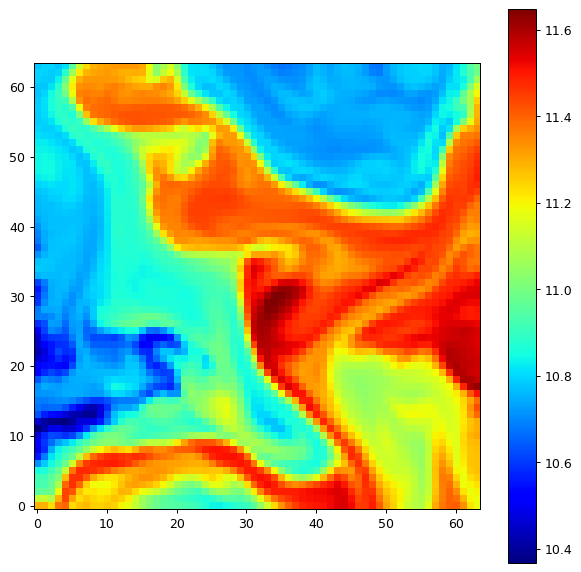

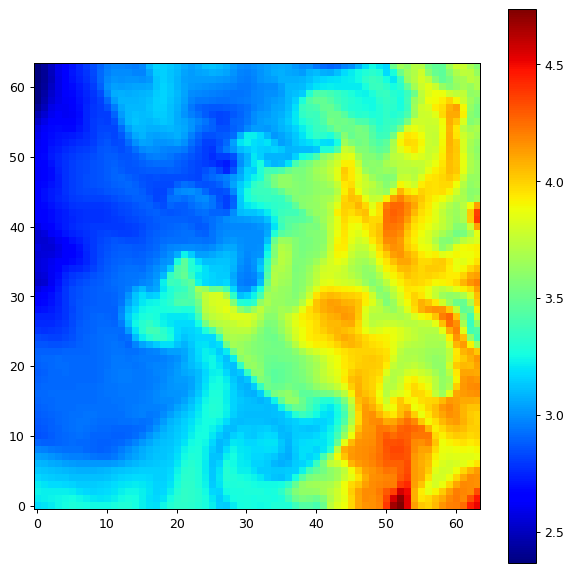

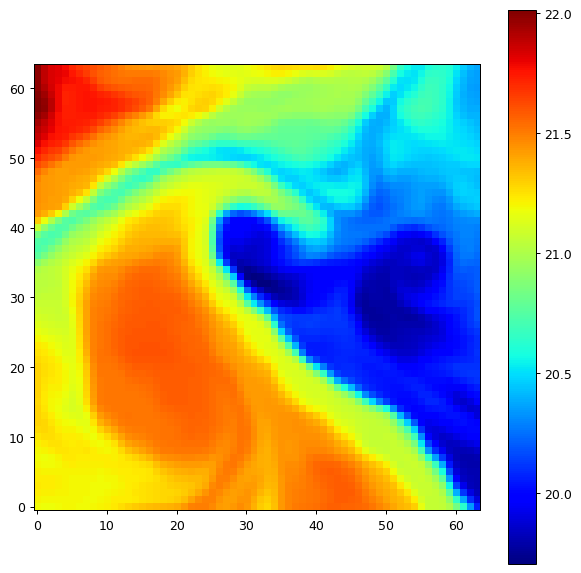

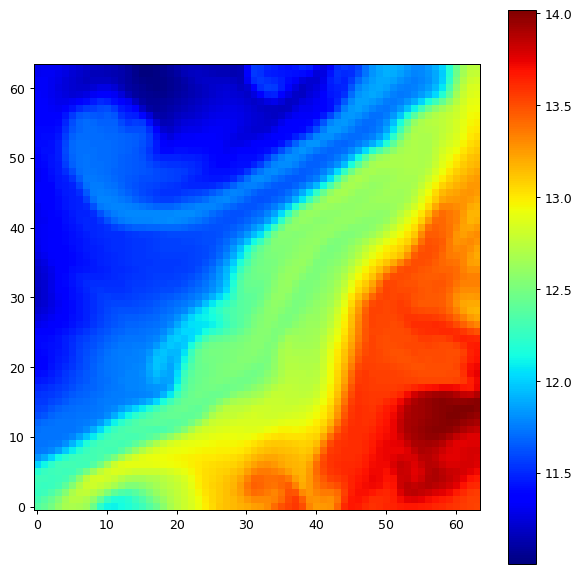

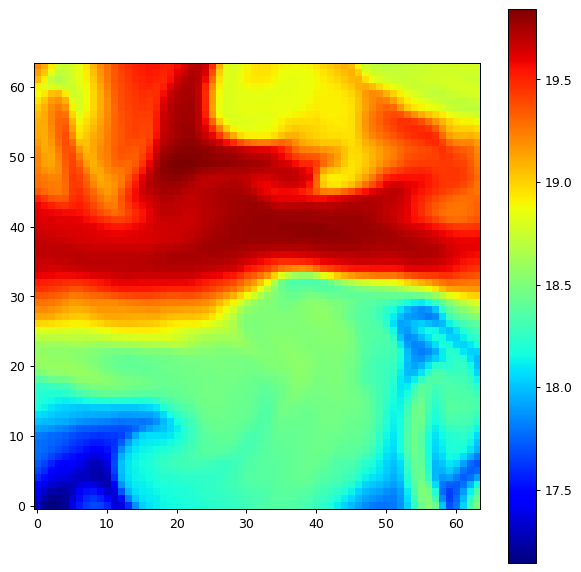

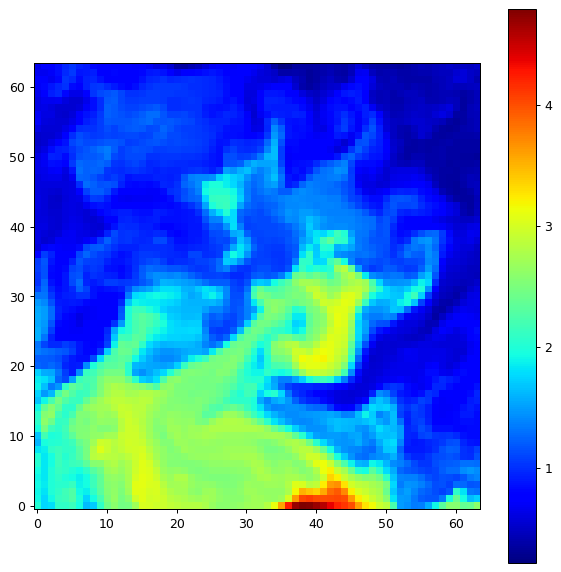

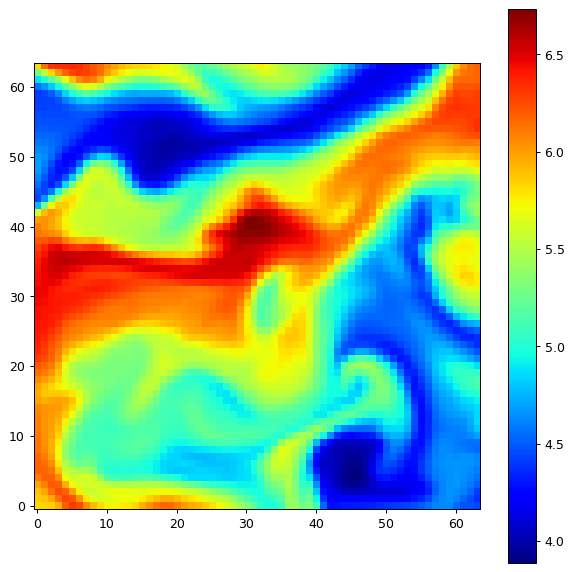

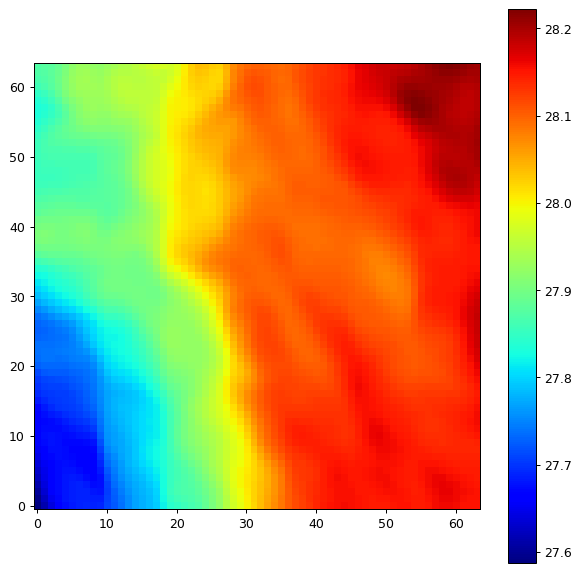

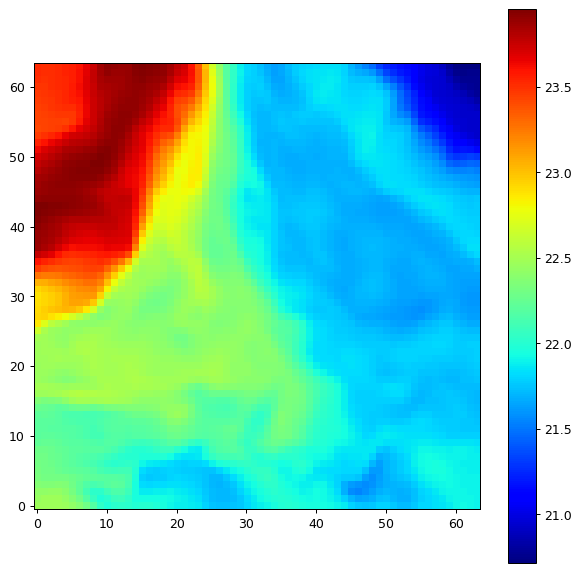

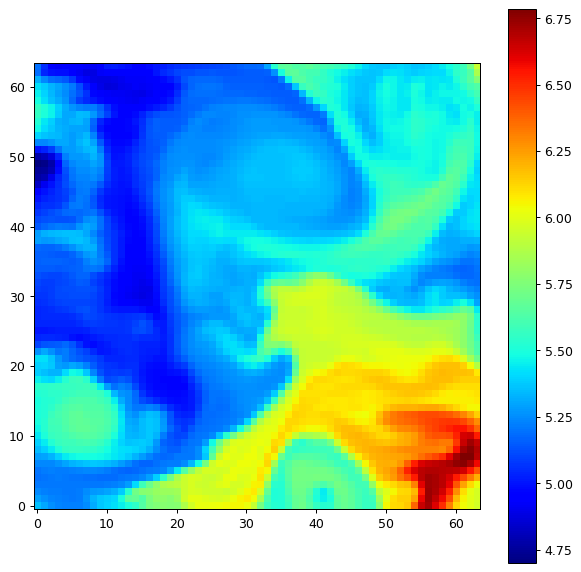

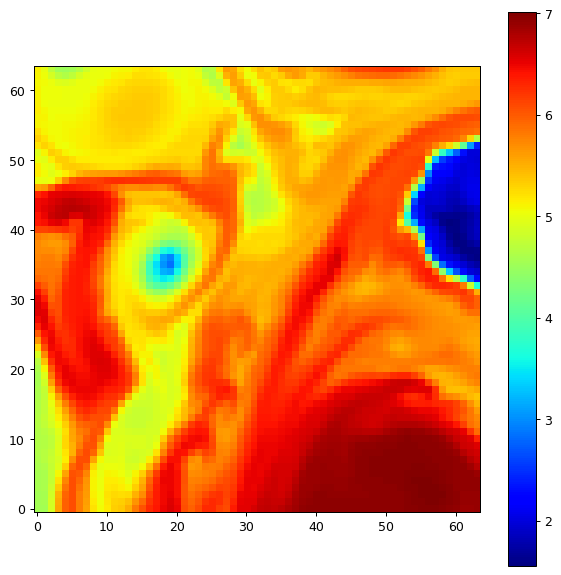

In [17]:
for img in imgs:
    plt.figure(figsize=(8, 8), dpi=90)
    im = plt.imshow(img[2], origin='lower', cmap='jet')
    plt.colorbar(im)
    plt.show()

In [36]:
img[2]

array([[-1.868817 , -1.8688064, -1.8694301, ..., -1.8644925, -1.8637562,
        -1.8645347],
       [-1.8677281, -1.8682638, -1.8690144, ..., -1.8644708, -1.8640054,
        -1.8641361],
       [-1.8670863, -1.868531 , -1.8693634, ..., -1.8637489, -1.8645443,
        -1.864546 ],
       ...,
       [-1.8697902, -1.8698397, -1.8699505, ..., -1.8575621, -1.8571723,
        -1.8567715],
       [-1.8699198, -1.8699011, -1.8699557, ..., -1.857086 , -1.8567749,
        -1.8559121],
       [-1.8698772, -1.8699254, -1.8701295, ..., -1.8559834, -1.8545666,
        -1.8534614]], shape=(64, 64), dtype=float32)

In [ ]:
# aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://llc/native_grid_dbof_training_data/script_test_00/ --human-readable
#
# aws --endpoint https://s3-west.nrp-nautilus.io s3 rm s3://llc/native_grid_dbof_training_data/script_test_00/ --recursive --dryrun